# AFD-CNN Evaluation on MobiFall / MobiAct Data

Applies the **SisFall fall-peak random-balanced model** (`model/sisfall_fall_peak_random_balanced_model.ckpt`) to the MobiAct dataset and reports a confusion matrix.

**Windowing strategy:**
- **Falls** (FOL, FKL, BSC, SDL): sliding window (step = 0.25 s) applied **only to the annotated fall-event phase** of each recording (rows where `label == fall_code`), not the pre-fall or lying period.
- **ADLs** (WAL, JOG, JUM, STU, STN, SCH, CHU): non-overlapping 2 s windows (step = 2 s) across the full recording.

**Preprocessing:**
- MobiFall accelerometer is in m/s²; converted to g (÷ 9.81) before normalization.
- Resampled from 200 Hz → 100 Hz (AFD-CNN training rate).
- Normalized to [0, 255] matching SisFall ADXL345 13-bit encoding: `(g × 256 + 4096) / 8192 × 255`.
- Input layout: **repeat-acc** — 1200-value vector = 600-value acc flattened, repeated twice.

**MobiFall → model class mapping:**

| MobiFall code | Activity | Model class |
|---|---|---|
| FOL, FKL, BSC, SDL | Fall | 0 — Fall |
| WAL | Walking | 2 — Walk |
| JOG | Jogging | 3 — Jog |
| JUM | Jumping | 4 — Jump |
| STU | Stairs up | 5 — Up-stairs |
| STN | Stairs down | 6 — Down-stairs |
| SCH | Stand to sit | 7 — Stand→Sit |
| CHU | Sit to stand | 9 — Sit→Stand |

## 0. Imports

In [1]:
import os
import sys
import importlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.signal import resample_poly
from collections import defaultdict

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC = '/home/ubuntu/git/FD-CNN/src'
if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)
import cnn as cnn_module
importlib.reload(cnn_module)

print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)

I0000 00:00:1776805707.887754  107035 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
TensorFlow: 2.21.0
NumPy: 2.4.4


## 1. Constants

In [2]:
ANN_PATH  = 'MobiFall_dataset/Annotated Data'
MODEL_CKPT = 'model/sisfall_fall_peak_random_balanced_model.ckpt'

FS_MOBIFALL = 200   # Hz — MobiAct sample rate
FS_CNN      = 100   # Hz — AFD-CNN training rate
WIN_LEN     = 200   # samples at 100 Hz = 2 s
FALL_STEP   = 25    # samples at 100 Hz = 0.25 s  (dense scan of short fall event)
ADL_STEP    = 200   # samples at 100 Hz = 2 s     (non-overlapping for ADLs)
BATCH_SIZE  = 512

# Model output classes
CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
CLASS_NAMES = {
    0: 'Fall',
    2: 'Walk',
    3: 'Jog',
    4: 'Jump',
    5: 'Up-stairs',
    6: 'Down-stairs',
    7: 'Stand→Sit',
    9: 'Sit→Stand',
}
CLASS_COLORS = {
    0: '#e84040',
    2: '#4a8fd4',
    3: '#56b56e',
    4: '#e09c30',
    5: '#9b6bd4',
    6: '#d47bb5',
    7: '#888888',
    9: '#aaaaaa',
}

# MobiFall fall codes → model class 0
FALL_CODES = ['FOL', 'FKL', 'BSC', 'SDL']

# MobiFall ADL codes → model class IDs
MOBI_TO_CLASS = {
    'WAL': 2,
    'JOG': 3,
    'JUM': 4,
    'STU': 5,
    'STN': 6,
    'SCH': 7,
    'CHU': 9,
}

FALL_DESCRIPTIONS = {
    'FOL': 'Forward-lying',
    'FKL': 'Front-knees-lying',
    'BSC': 'Back-sitting-chair',
    'SDL': 'Sideward-lying',
}

print('Model:', MODEL_CKPT)
print(f'Window: {WIN_LEN} samples @ {FS_CNN} Hz = {WIN_LEN/FS_CNN:.1f} s')
print(f'Fall step: {FALL_STEP} samples = {FALL_STEP/FS_CNN:.2f} s')
print(f'ADL  step: {ADL_STEP}  samples = {ADL_STEP/FS_CNN:.2f} s')

Model: model/sisfall_fall_peak_random_balanced_model.ckpt
Window: 200 samples @ 100 Hz = 2.0 s
Fall step: 25 samples = 0.25 s
ADL  step: 200  samples = 2.00 s


## 2. Load AFD-CNN model

In [3]:
tf.reset_default_graph()
x_ph              = tf.placeholder(tf.float32, [None, 1200], name='input')
logits_op, keep   = cnn_module.fall_net(x_ph)
probs_op          = tf.nn.softmax(logits_op)

saver = tf.train.Saver()
sess  = tf.Session()
saver.restore(sess, MODEL_CKPT)

print('Model restored from:', MODEL_CKPT)
print('Output logits shape:', logits_op.shape)

Model restored from: model/sisfall_fall_peak_random_balanced_model.ckpt
Output logits shape: (?, 8)


E0000 00:00:1776805709.570375  107035 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776805709.576307  107035 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 3. Preprocessing helpers

In [4]:
def extract_windows(arr_ms2, win_len, step, fs_in=FS_MOBIFALL, fs_out=FS_CNN):
    """
    Convert, resample, and window a (N, 3) accelerometer array (m/s²).

    Steps
    -----
    1. m/s² → g  (÷ 9.81)
    2. Polyphase resample from fs_in to fs_out
    3. Apply SisFall ADXL345 normalization: (g × 256 + 4096) / 8192 × 255 → [0, 255]
    4. Slide window of size win_len with given step
    5. Each window flattened to (600,) and repeated to (1200,) — repeat-acc layout

    Returns
    -------
    np.ndarray of shape (N_windows, 1200), dtype float32, range [0, 255]
    """
    if len(arr_ms2) < 1:
        return np.empty((0, 1200), dtype=np.float32)

    arr_g      = arr_ms2 / 9.81
    arr_resamp = resample_poly(arr_g.astype(np.float32), fs_out, fs_in, axis=0)

    # SisFall ADXL345 normalization: ADXL345 is 13-bit ±16 g → 256 counts/g
    adc        = arr_resamp * 256.0
    arr_norm   = np.clip((adc + 4096.0) / 8192.0 * 255.0, 0.0, 255.0).astype(np.float32)

    n = len(arr_norm)
    windows = []
    for off in range(0, n - win_len + 1, step):
        chunk = arr_norm[off: off + win_len]  # (win_len, 3)
        flat  = chunk.flatten()               # (600,)
        windows.append(np.concatenate([flat, flat]))  # (1200,) repeat-acc

    return np.array(windows, dtype=np.float32) if windows else np.empty((0, 1200), dtype=np.float32)

## 4. Extract windows — falls (fall-event phase only)

In [5]:
fall_windows_list  = []
fall_labels_gt     = []
fall_source_codes  = []

for code in FALL_CODES:
    code_dir  = os.path.join(ANN_PATH, code)
    files     = sorted(f for f in os.listdir(code_dir) if f.endswith('.csv'))
    n_wins_code = 0

    for fname in files:
        df = pd.read_csv(os.path.join(code_dir, fname))

        # Keep only the fall-event rows (exclude pre-fall STD and post-fall LYI)
        fall_rows = df[df['label'] == code]
        if len(fall_rows) == 0:
            continue

        arr = fall_rows[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32)
        wins = extract_windows(arr, win_len=WIN_LEN, step=FALL_STEP)

        if len(wins) > 0:
            fall_windows_list.append(wins)
            fall_labels_gt.extend([0] * len(wins))
            fall_source_codes.extend([code] * len(wins))
            n_wins_code += len(wins)

    print(f'{code} ({FALL_DESCRIPTIONS[code]}): {len(files)} files → {n_wins_code} fall-event windows')

fall_windows = np.vstack(fall_windows_list) if fall_windows_list else np.empty((0, 1200), dtype=np.float32)
print(f'\nTotal fall windows : {len(fall_windows)}')

FOL (Forward-lying): 192 files → 212 fall-event windows
FKL (Front-knees-lying): 192 files → 353 fall-event windows
BSC (Back-sitting-chair): 191 files → 752 fall-event windows
SDL (Sideward-lying): 192 files → 449 fall-event windows

Total fall windows : 1766


## 5. Extract windows — ADLs (non-overlapping 2 s)

In [6]:
adl_windows_list = []
adl_labels_gt    = []
adl_source_codes = []

for code, class_id in MOBI_TO_CLASS.items():
    code_dir = os.path.join(ANN_PATH, code)
    if not os.path.isdir(code_dir):
        print(f'{code}: directory not found, skipping')
        continue

    files = sorted(f for f in os.listdir(code_dir) if f.endswith('.csv'))
    n_wins_code = 0

    for fname in files:
        df   = pd.read_csv(os.path.join(code_dir, fname))
        arr  = df[['acc_x', 'acc_y', 'acc_z']].to_numpy(dtype=np.float32)
        wins = extract_windows(arr, win_len=WIN_LEN, step=ADL_STEP)

        if len(wins) > 0:
            adl_windows_list.append(wins)
            adl_labels_gt.extend([class_id] * len(wins))
            adl_source_codes.extend([code] * len(wins))
            n_wins_code += len(wins)

    print(f'{code} → class {class_id} ({CLASS_NAMES[class_id]}): '
          f'{len(files)} files → {n_wins_code} windows')

adl_windows = np.vstack(adl_windows_list) if adl_windows_list else np.empty((0, 1200), dtype=np.float32)
print(f'\nTotal ADL windows  : {len(adl_windows)}')

WAL → class 2 (Walk): 61 files → 9090 windows
JOG → class 3 (Jog): 183 files → 2563 windows
JUM → class 4 (Jump): 183 files → 2562 windows
STU → class 5 (Up-stairs): 364 files → 1455 windows
STN → class 6 (Down-stairs): 365 files → 1460 windows
SCH → class 7 (Stand→Sit): 365 files → 731 windows
CHU → class 9 (Sit→Stand): 114 files → 228 windows

Total ADL windows  : 18089


In [7]:
all_windows = np.vstack([fall_windows, adl_windows])
all_gt      = np.array(fall_labels_gt + adl_labels_gt, dtype=np.int32)

print(f'Total windows      : {len(all_windows):,}')
print(f'  Fall             : {len(fall_windows):,}')
print(f'  ADL              : {len(adl_windows):,}')
print(f'Window tensor      : {all_windows.shape}  [{all_windows.min():.1f}, {all_windows.max():.1f}]')
print()
print('Class distribution (ground truth):')
for cls in CLASS_LIST:
    n = (all_gt == cls).sum()
    print(f'  {CLASS_NAMES[cls]:12s} (class {cls}): {n:,}')

Total windows      : 19,855
  Fall             : 1,766
  ADL              : 18,089
Window tensor      : (19855, 1200)  [111.3, 144.4]

Class distribution (ground truth):
  Fall         (class 0): 1,766
  Walk         (class 2): 9,090
  Jog          (class 3): 2,563
  Jump         (class 4): 2,562
  Up-stairs    (class 5): 1,455
  Down-stairs  (class 6): 1,460
  Stand→Sit    (class 7): 731
  Sit→Stand    (class 9): 228


## 6. Run inference

In [8]:
all_probs_list  = []
all_logits_list = []

for start in range(0, len(all_windows), BATCH_SIZE):
    batch = all_windows[start: start + BATCH_SIZE]
    logits_b, probs_b = sess.run(
        [logits_op, probs_op],
        feed_dict={x_ph: batch, keep: 1.0},
    )
    all_probs_list.append(probs_b)
    all_logits_list.append(logits_b)

all_probs  = np.vstack(all_probs_list)   # (N, 8)
all_logits = np.vstack(all_logits_list)  # (N, 8)

pred_idx    = np.argmax(all_probs, axis=1)
all_pred    = np.array([CLASS_LIST[i] for i in pred_idx], dtype=np.int32)
fall_idx    = CLASS_LIST.index(0)
fall_probs  = all_probs[:, fall_idx]

print(f'Inference complete — {len(all_windows):,} windows')
print()
print('Predicted class distribution:')
for cls in CLASS_LIST:
    n = (all_pred == cls).sum()
    print(f'  {CLASS_NAMES[cls]:12s}: {n:,}')

Inference complete — 19,855 windows

Predicted class distribution:
  Fall        : 16,976
  Walk        : 569
  Jog         : 479
  Jump        : 343
  Up-stairs   : 242
  Down-stairs : 918
  Stand→Sit   : 42
  Sit→Stand   : 286


## 7. Confusion matrix

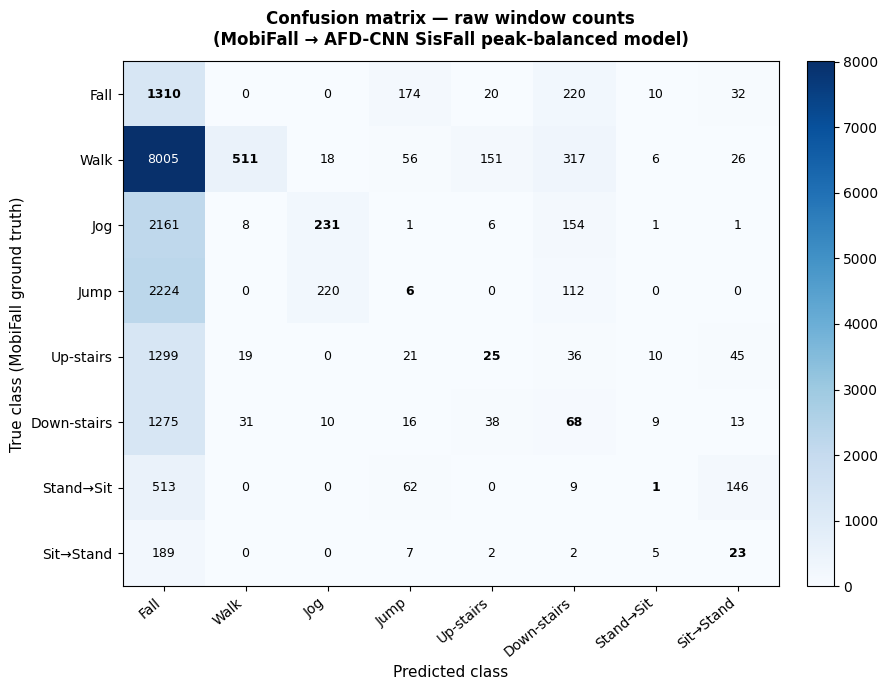

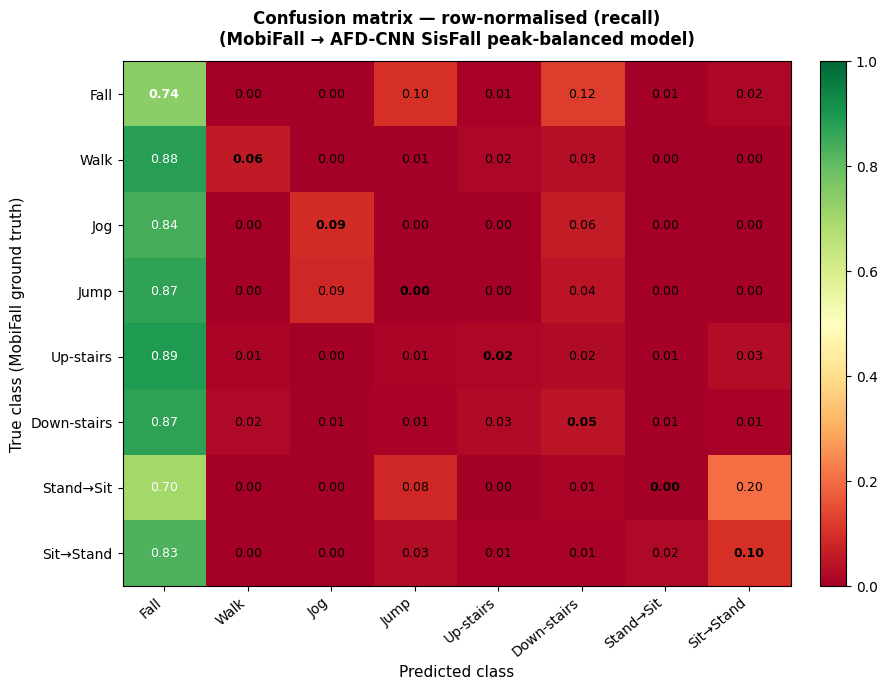

In [9]:
n_classes   = len(CLASS_LIST)
cls_to_idx  = {cls: i for i, cls in enumerate(CLASS_LIST)}
class_labels = [CLASS_NAMES[c] for c in CLASS_LIST]

# Raw count confusion matrix
cm = np.zeros((n_classes, n_classes), dtype=np.int64)
for gt, pr in zip(all_gt, all_pred):
    cm[cls_to_idx[gt], cls_to_idx[pr]] += 1

# Row-normalised (recall) matrix
row_sums  = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_normed = cm / row_sums

def plot_confusion_matrix(matrix, labels, title, fmt, cmap, vmin=None, vmax=None, figsize=(9, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, interpolation='nearest', cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Predicted class', fontsize=11)
    ax.set_ylabel('True class (MobiFall ground truth)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    thresh = (matrix.max() + matrix.min()) / 2.0 if vmin is None else (vmin + vmax) / 2.0
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = matrix[i, j]
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, format(val, fmt), ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold' if i == j else 'normal')

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    cm, class_labels,
    title='Confusion matrix — raw window counts\n(MobiFall → AFD-CNN SisFall peak-balanced model)',
    fmt='d', cmap='Blues',
)

plot_confusion_matrix(
    cm_normed, class_labels,
    title='Confusion matrix — row-normalised (recall)\n(MobiFall → AFD-CNN SisFall peak-balanced model)',
    fmt='.2f', cmap='RdYlGn', vmin=0.0, vmax=1.0,
)

## 8. Per-class metrics

In [10]:
rows = []
for i, cls in enumerate(CLASS_LIST):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp           # missed — predicted as something else
    fp = cm[:, i].sum() - tp           # false alarms from other classes
    tn = cm.sum() - tp - fn - fp

    n_true  = cm[i, :].sum()
    recall  = tp / n_true if n_true > 0 else 0.0
    prec_d  = tp + fp
    precision = tp / prec_d if prec_d > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    spec_d = fp + tn
    specificity = tn / spec_d if spec_d > 0 else 0.0

    rows.append({
        'Class': CLASS_NAMES[cls],
        'N true': n_true,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Recall (sensitivity)': recall,
        'Precision': precision,
        'F1': f1,
        'Specificity': specificity,
    })

metrics_df = pd.DataFrame(rows)

def _highlight_fall(row):
    color = 'background-color: #922b21; color: white' if row['Class'] == 'Fall' else ''
    return [color] * len(row)

styled = (
    metrics_df.style
    .apply(_highlight_fall, axis=1)
    .format({
        'Recall (sensitivity)': '{:.3f}',
        'Precision': '{:.3f}',
        'F1': '{:.3f}',
        'Specificity': '{:.3f}',
        'N true': '{:,}',
        'TP': '{:,}',
        'FP': '{:,}',
        'FN': '{:,}',
    })
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_caption('Per-class metrics — AFD-CNN on MobiFall')
    .background_gradient(subset=['Recall (sensitivity)', 'F1'], cmap='RdYlGn', vmin=0, vmax=1)
)
display(styled)

,Class,N true,TP,FP,FN,Recall (sensitivity),Precision,F1,Specificity
0,Fall,"1,766","1,310","15,666",456,0.742,0.077,0.140,0.134
1,Walk,"9,090",511,58,"8,579",0.056,0.898,0.106,0.995
2,Jog,"2,563",231,248,"2,332",0.090,0.482,0.152,0.986
3,Jump,"2,562",6,337,"2,556",0.002,0.017,0.004,0.981
4,Up-stairs,"1,455",25,217,"1,430",0.017,0.103,0.029,0.988
5,Down-stairs,"1,460",68,850,"1,392",0.047,0.074,0.057,0.954
6,Stand→Sit,731,1,41,730,0.001,0.024,0.003,0.998
7,Sit→Stand,228,23,263,205,0.101,0.080,0.089,0.987


## 9. Fall detection summary

In [11]:
# Binary fall-detection summary: Fall (class 0) vs. everything else
is_fall_gt   = (all_gt   == 0)
is_fall_pred = (all_pred == 0)

tp_fall = ( is_fall_gt &  is_fall_pred).sum()
fn_fall = ( is_fall_gt & ~is_fall_pred).sum()
fp_fall = (~is_fall_gt &  is_fall_pred).sum()
tn_fall = (~is_fall_gt & ~is_fall_pred).sum()

sensitivity = tp_fall / (tp_fall + fn_fall)
specificity = tn_fall / (tn_fall + fp_fall)
accuracy    = (tp_fall + tn_fall) / len(all_gt)

print('=== Binary fall detection (Fall vs. all ADLs) ===')
print(f'  True  Positives (fall correctly detected)   : {tp_fall:,}')
print(f'  False Negatives (fall missed)               : {fn_fall:,}')
print(f'  False Positives (ADL flagged as fall)       : {fp_fall:,}')
print(f'  True  Negatives (ADL correctly rejected)    : {tn_fall:,}')
print()
print(f'  Sensitivity (recall for falls) : {sensitivity:.3f}')
print(f'  Specificity (recall for ADLs)  : {specificity:.3f}')
print(f'  Overall accuracy               : {accuracy:.3f}')
print()

# Per fall type
print('--- Recall per fall type ---')
for code in FALL_CODES:
    code_mask   = np.array(fall_source_codes) == code
    pred_code   = all_pred[:len(fall_labels_gt)][code_mask]
    recall_code = (pred_code == 0).mean() if len(pred_code) > 0 else 0.0
    print(f'  {code} ({FALL_DESCRIPTIONS[code]:20s}): '
          f'{(pred_code == 0).sum():3d}/{len(pred_code):3d} windows = {recall_code:.3f}')

=== Binary fall detection (Fall vs. all ADLs) ===
  True  Positives (fall correctly detected)   : 1,310
  False Negatives (fall missed)               : 456
  False Positives (ADL flagged as fall)       : 15,666
  True  Negatives (ADL correctly rejected)    : 2,423

  Sensitivity (recall for falls) : 0.742
  Specificity (recall for ADLs)  : 0.134
  Overall accuracy               : 0.188

--- Recall per fall type ---
  FOL (Forward-lying       ): 203/212 windows = 0.958
  FKL (Front-knees-lying   ): 324/353 windows = 0.918
  BSC (Back-sitting-chair  ): 410/752 windows = 0.545
  SDL (Sideward-lying      ): 373/449 windows = 0.831


## 10. P(Fall) distributions — falls vs ADLs

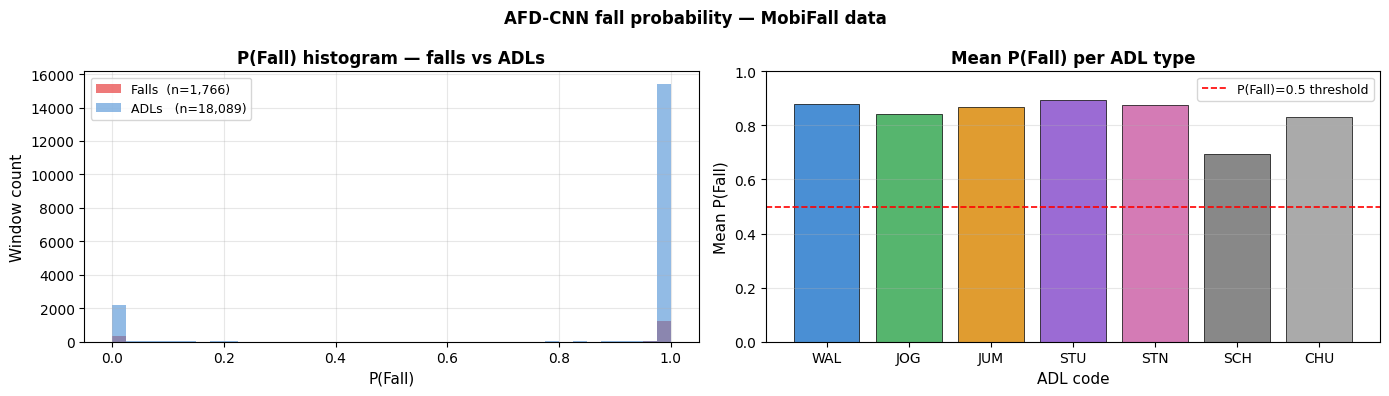

Falls  — mean P(Fall): 0.742  |  median: 1.000
ADLs   — mean P(Fall): 0.865  |  median: 1.000


In [12]:
n_fall_wins = len(fall_windows)
p_fall_falls = fall_probs[:n_fall_wins]                     # P(Fall) for actual falls
p_fall_adls  = fall_probs[n_fall_wins:]                     # P(Fall) for ADLs

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Histogram
bins = np.linspace(0, 1, 41)
axes[0].hist(p_fall_falls, bins=bins, color='#e84040', alpha=0.7, label=f'Falls  (n={len(p_fall_falls):,})')
axes[0].hist(p_fall_adls,  bins=bins, color='#4a8fd4', alpha=0.6, label=f'ADLs   (n={len(p_fall_adls):,})')
axes[0].set_xlabel('P(Fall)', fontsize=11)
axes[0].set_ylabel('Window count', fontsize=11)
axes[0].set_title('P(Fall) histogram — falls vs ADLs', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Per ADL code: mean P(Fall)
adl_code_arr = np.array(adl_source_codes)
adl_probs_arr = p_fall_adls
codes_ordered = list(MOBI_TO_CLASS.keys())
mean_pfalls = [adl_probs_arr[adl_code_arr == c].mean() for c in codes_ordered]

bar_colors = [CLASS_COLORS[MOBI_TO_CLASS[c]] for c in codes_ordered]
axes[1].bar(codes_ordered, mean_pfalls, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='P(Fall)=0.5 threshold')
axes[1].set_xlabel('ADL code', fontsize=11)
axes[1].set_ylabel('Mean P(Fall)', fontsize=11)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Mean P(Fall) per ADL type', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('AFD-CNN fall probability — MobiFall data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Falls  — mean P(Fall): {p_fall_falls.mean():.3f}  |  median: {np.median(p_fall_falls):.3f}')
print(f'ADLs   — mean P(Fall): {p_fall_adls.mean():.3f}  |  median: {np.median(p_fall_adls):.3f}')

## 11. Per-fall-type recall bar chart

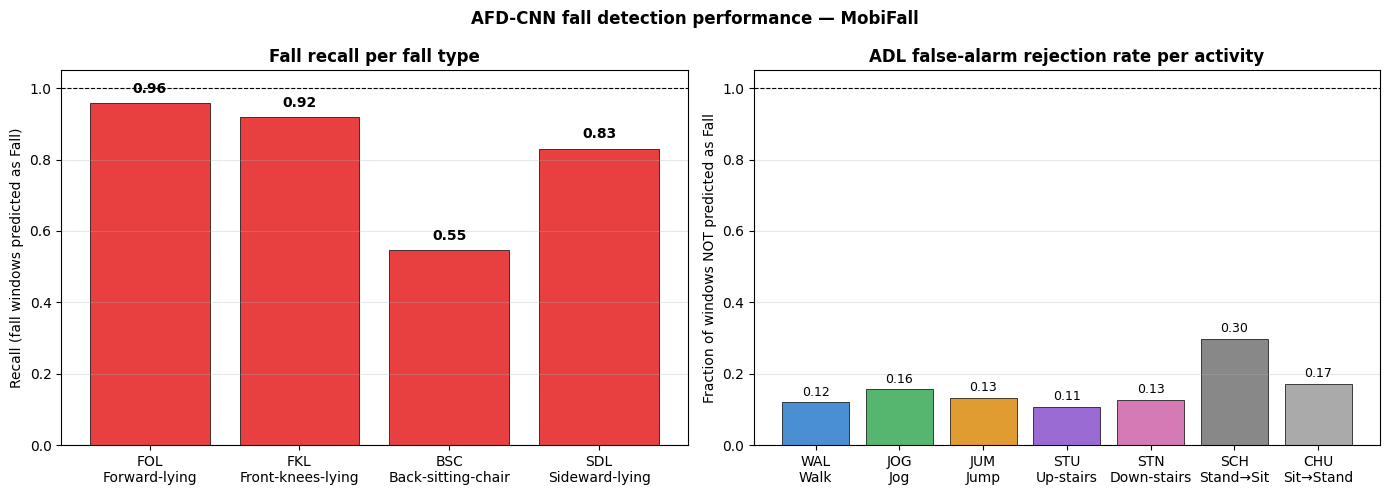

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: recall per fall type
fall_recalls = []
fall_code_labels = []
for code in FALL_CODES:
    code_mask = np.array(fall_source_codes) == code
    pred_code = all_pred[:len(fall_labels_gt)][code_mask]
    recall = (pred_code == 0).mean() if len(pred_code) > 0 else 0.0
    fall_recalls.append(recall)
    fall_code_labels.append(f'{code}\n{FALL_DESCRIPTIONS[code]}')

bar_fall = axes[0].bar(fall_code_labels, fall_recalls, color='#e84040', edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Recall (fall windows predicted as Fall)', fontsize=10)
axes[0].set_title('Fall recall per fall type', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bar_fall, fall_recalls):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: specificity per ADL type (1 - false alarm rate)
adl_specificities = []
adl_labels_plot = []
for code, class_id in MOBI_TO_CLASS.items():
    code_mask  = np.array(adl_source_codes) == code
    pred_code  = all_pred[len(fall_labels_gt):][code_mask]
    specificity_code = (pred_code != 0).mean() if len(pred_code) > 0 else 0.0  # fraction NOT predicted as fall
    adl_specificities.append(specificity_code)
    adl_labels_plot.append(f'{code}\n{CLASS_NAMES[class_id]}')

bar_adl = axes[1].bar(adl_labels_plot, adl_specificities,
                      color=[CLASS_COLORS[MOBI_TO_CLASS[c]] for c in MOBI_TO_CLASS],
                      edgecolor='black', linewidth=0.5)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Fraction of windows NOT predicted as Fall', fontsize=10)
axes[1].set_title('ADL false-alarm rejection rate per activity', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, v in zip(bar_adl, adl_specificities):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9)

fig.suptitle('AFD-CNN fall detection performance — MobiFall', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Most-confident example windows per predicted class

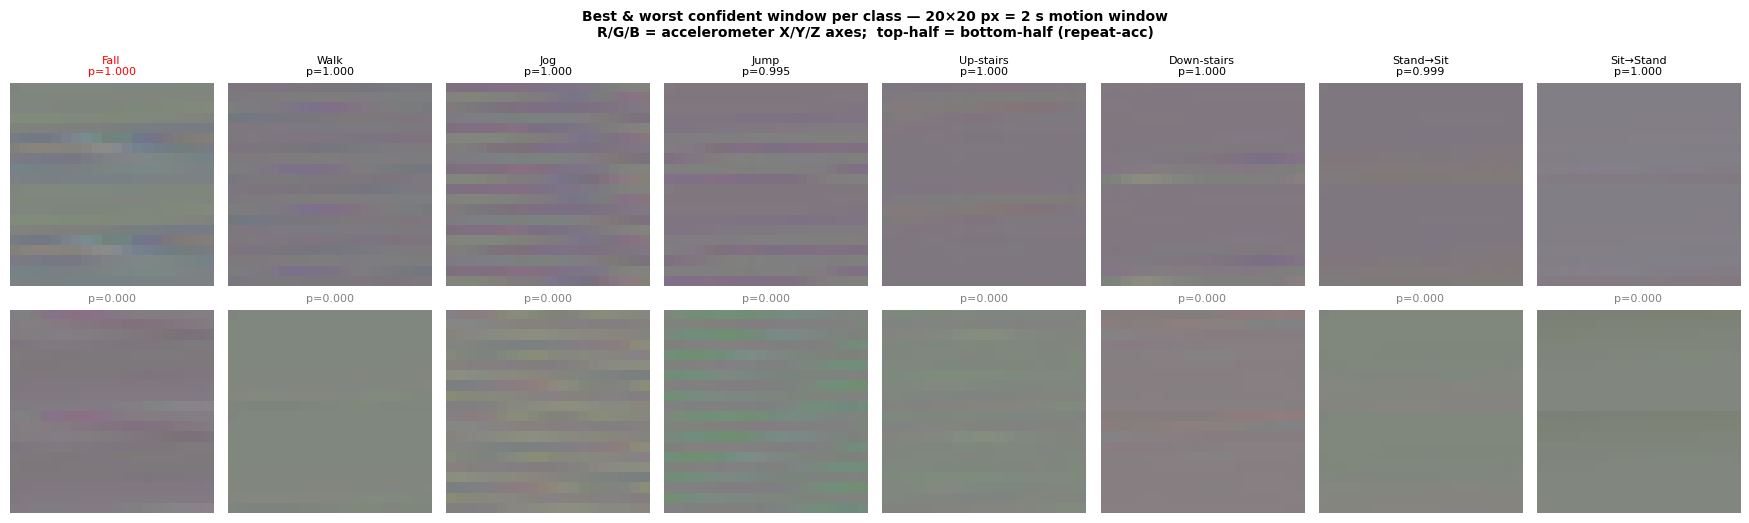

In [14]:
fig, axes = plt.subplots(2, n_classes, figsize=(2.2 * n_classes, 5.5))

for col, cls in enumerate(CLASS_LIST):
    cls_idx = CLASS_LIST.index(cls)

    # Best window from correct fall predictions (TP for Fall, or best ADL prediction)
    if cls == 0:  # Fall — pick from fall windows only
        cand_mask = np.arange(len(fall_windows))
        scores    = all_probs[:len(fall_windows), cls_idx]
    else:  # ADL — pick from ADL windows of the matching ground-truth class
        gt_mask   = np.array(adl_labels_gt) == cls
        cand_mask = np.where(gt_mask)[0] + len(fall_windows)
        scores    = all_probs[cand_mask, cls_idx]

    best_local  = int(np.argmax(scores))
    best_global = cand_mask[best_local] if hasattr(cand_mask, '__len__') else best_local
    best_prob   = scores[best_local]

    img = all_windows[best_global].reshape(20, 20, 3) / 255.0
    name  = CLASS_NAMES[cls]
    color = 'red' if cls == 0 else 'black'

    axes[0][col].imshow(img)
    axes[0][col].set_title(f'{name}\np={best_prob:.3f}', fontsize=8, color=color)
    axes[0][col].axis('off')

    # Also show a low-confidence window for the same true class
    worst_local  = int(np.argmin(scores))
    worst_global = cand_mask[worst_local] if hasattr(cand_mask, '__len__') else worst_local
    worst_prob   = scores[worst_local]
    img2 = all_windows[worst_global].reshape(20, 20, 3) / 255.0

    axes[1][col].imshow(img2)
    axes[1][col].set_title(f'p={worst_prob:.3f}', fontsize=8, color='grey')
    axes[1][col].axis('off')

axes[0][0].set_ylabel('Best (most\nconfident)', fontsize=8, rotation=0, labelpad=50)
axes[1][0].set_ylabel('Worst (least\nconfident)', fontsize=8, rotation=0, labelpad=50)

fig.suptitle(
    'Best & worst confident window per class — 20×20 px = 2 s motion window\n'
    'R/G/B = accelerometer X/Y/Z axes;  top-half = bottom-half (repeat-acc)',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
plt.show()

In [15]:
sess.close()
print('TF session closed.')

TF session closed.
